<a href="https://colab.research.google.com/github/PrajwalKamble369/PyTorchWithProjects/blob/main/Tabular_Data_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: prajwalkamble369
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 2.08MB/s]

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset,DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
data_df = pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [4]:
data_df.dropna(inplace=True)
data_df.drop(["id"],axis=1,inplace=True)
print(data_df.shape)

(18185, 11)


In [5]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [6]:
print(data_df["Class"].unique())

[1 0]


In [7]:
print(data_df["Class"].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [8]:
orignal_df = data_df.copy()

for column in data_df.columns:
  data_df[column] = data_df[column]/ data_df[column].abs().max()
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [9]:
X = np.array(data_df.iloc[:,:-1])
y = np.array(data_df.iloc[:,-1])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

In [11]:
X_test,X_val, y_test,y_val = train_test_split(X_test,y_test,test_size=0.5)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [51]:
class CustomDataset(Dataset):
  def __init__(self,X,y):
    self.X = torch.tensor(X,dtype=torch.float32).to(device)
    self.y = torch.tensor(y,dtype=torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self,index):
    return self.X[index], self.y[index]


In [52]:
training_data = CustomDataset(X_train,y_train)
validation_data = CustomDataset(X_val,y_val)
testing_data = CustomDataset(X_test,y_test)

In [53]:
train_dataloader = DataLoader(training_data, batch_size=32,shuffle=True)
validation_dataloader = DataLoader(validation_data,batch_size=32,shuffle=False)
testing_dataloader = DataLoader(testing_data,batch_size=32,shuffle=False)

In [54]:
for x, y in train_dataloader:
  print(x)
  print("=======================")
  print(y)
  break

tensor([[0.8243, 0.8278, 0.8708, 0.9108, 0.7908, 0.9079, 0.6523, 0.7250, 0.8601,
         0.5393],
        [0.9077, 0.8631, 0.9137, 0.9091, 0.8741, 0.9528, 0.7853, 0.7693, 0.8412,
         0.5359],
        [0.6665, 0.9071, 0.6419, 0.9804, 0.6390, 0.8164, 0.6433, 0.7229, 0.6994,
         0.8017],
        [0.8631, 0.8581, 0.8735, 0.9192, 0.8300, 0.9290, 0.7125, 0.7547, 0.8310,
         0.5574],
        [0.7673, 0.8218, 0.8121, 0.9262, 0.7295, 0.8759, 0.6563, 0.7013, 0.8556,
         0.5741],
        [0.5994, 0.7936, 0.6690, 0.9569, 0.5714, 0.7742, 0.8877, 0.6550, 0.7662,
         0.6731],
        [0.5082, 0.7834, 0.5686, 0.9775, 0.4823, 0.7129, 0.5847, 0.6185, 0.7287,
         0.7817],
        [0.7604, 0.7973, 0.8291, 0.9138, 0.7228, 0.8720, 0.8165, 0.6962, 0.8605,
         0.5456],
        [0.5985, 0.8526, 0.6141, 0.9784, 0.5701, 0.7736, 0.6999, 0.6756, 0.7191,
         0.7877],
        [0.8584, 0.8444, 0.8834, 0.9122, 0.8157, 0.9265, 0.6612, 0.7333, 0.8755,
         0.5423],
        [0

In [55]:
HIDDEN_NUERONS = 10
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.input_layer = nn.Linear(X.shape[1],HIDDEN_NUERONS)
    self.linear = nn.Linear(HIDDEN_NUERONS,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    x = self.input_layer(x)
    x = self.linear(x)
    x = self.sigmoid(x)
    return x

model = MyModel().to(device)

In [56]:
summary(model,(X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [57]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(),lr= 1e-3)

In [58]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_accuracy_train_plot = []
total_acuuracy_validation_plot = []

epochs = 10
for epoch in range(epochs):
  total_accuracy_train = 0
  total_loss_train = 0
  total_accuracy_validation = 0
  total_loss_validation = 0

  for data in train_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss = criterion(prediction,labels)

    total_loss_train += batch_loss.item()

    acc = ((prediction).round() == labels).sum().item()

    total_accuracy_train += acc

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in validation_dataloader:
      inputs, labels = data

      prediction = model(inputs).squeeze(1)

      batch_loss = criterion(prediction,labels)

      total_loss_validation += batch_loss.item()

      acc = ((prediction).round() == labels).sum().item()

      total_accuracy_validation += acc
  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_validation/1000, 4))

  total_accuracy_train_plot.append(round(total_accuracy_train/training_data.__len__()*100,4))
  total_acuuracy_validation_plot.append(round(total_accuracy_validation/validation_data.__len__()*100,4))

  print(f"""
  Epoch no. {epoch+1}
    Train Loss: {round(total_loss_train/1000, 4)}
    Train Accuracy: {round(total_accuracy_train/training_data.__len__()*100,4)}
    Validation Loss: {round(total_loss_validation/1000, 4)}
    Validation Accuracy : {round(total_accuracy_validation/validation_data.__len__()*100,4)}
        """)
  print("="*25)


  Epoch no. 1 
    Train Loss: 0.2362 
    Train Accuracy: 82.6066
    Validation Loss: 0.0383
    Validation Accuracy : 97.7273
        

  Epoch no. 2 
    Train Loss: 0.1203 
    Train Accuracy: 97.4861
    Validation Loss: 0.0167
    Validation Accuracy : 98.1305
        

  Epoch no. 3 
    Train Loss: 0.0573 
    Train Accuracy: 98.256
    Validation Loss: 0.0094
    Validation Accuracy : 98.4238
        

  Epoch no. 4 
    Train Loss: 0.0362 
    Train Accuracy: 98.5152
    Validation Loss: 0.0069
    Validation Accuracy : 98.717
        

  Epoch no. 5 
    Train Loss: 0.0275 
    Train Accuracy: 98.5623
    Validation Loss: 0.0055
    Validation Accuracy : 98.7903
        

  Epoch no. 6 
    Train Loss: 0.0231 
    Train Accuracy: 98.6095
    Validation Loss: 0.0048
    Validation Accuracy : 98.717
        

  Epoch no. 7 
    Train Loss: 0.0205 
    Train Accuracy: 98.633
    Validation Loss: 0.0044
    Validation Accuracy : 98.7537
        

  Epoch no. 8 
    Train Loss:

In [59]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss_test = criterion(prediction,labels).item()
    total_loss_test += batch_loss_test

    acc = ((prediction).round() == labels).sum().item()

    total_acc_test += acc

print(round(total_acc_test/testing_data.__len__()*100,4))

98.4238


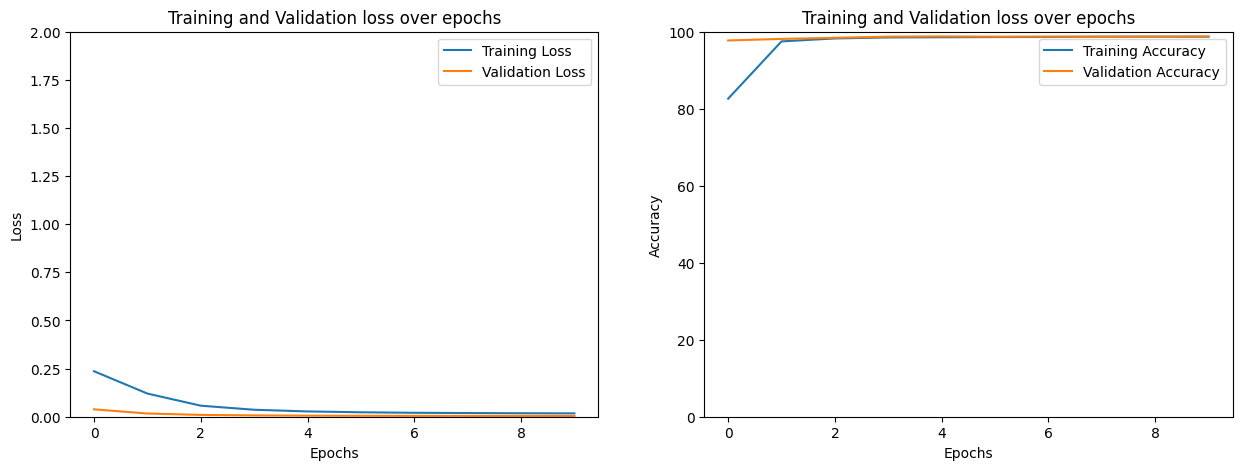

In [60]:
fig, axs = plt.subplots(nrows=1,ncols=2,figsize= (15,5))
axs[0].plot(total_loss_train_plot,label="Training Loss")
axs[0].plot(total_loss_validation_plot,label="Validation Loss")
axs[0].set_title("Training and Validation loss over epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].set_ylim([0,2])
axs[0].legend()

axs[1].plot(total_accuracy_train_plot,label="Training Accuracy")
axs[1].plot(total_acuuracy_validation_plot,label="Validation Accuracy")
axs[1].set_title("Training and Validation loss over epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].set_ylim([0,100])
axs[1].legend()

plt.show()

In [64]:
area = 2353/orignal_df['Area'].abs().max()

MajorAxisLength = 81/orignal_df['MajorAxisLength'].abs().max()

MinorAxisLength = 42/orignal_df['MinorAxisLength'].abs().max()

Eccentricity = 42/orignal_df['Eccentricity'].abs().max()

ConvexArea = 12/orignal_df['ConvexArea'].abs().max()

EquivDiameter= 33/orignal_df['EquivDiameter'].abs().max()

Extent = 98/orignal_df['Extent'].abs().max()

Perimeter = 927/orignal_df['Perimeter'].abs().max()

Roundness = 677/orignal_df['Roundness'].abs().max()

AspectRation = 24/orignal_df['AspectRation'].abs().max()

my_pred = model(torch.tensor([area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation],dtype=torch.float32).to(device))

In [67]:
round(my_pred.item())

0